# PPO from scratch — **V6_1: minibatched PPO on the parallel rollout**

The training half of the GPU-shaped rewrite. V6_0 built the *data* pipeline — 512 envs stepped
as one batch, a persistent `state` so episodes outlive collections, a rollout `Dataset` and a
shuffled `DataLoader`. V6_1 adds everything that turns that data into a trained policy, in the
shape a real large-model PPO loop has:

- a **critic**, whose values are recorded *during* collection (frozen, one batched forward per step);
- **GAE-λ over the (T, N) grid**, computed *before* flattening, with the autoreset bootstrap
  done correctly (goal → 0, time-limit → value of the real final state);
- the **update as epochs of minibatch SGD** over the shuffled loader — *inference batched wide,
  updates batched deep* — carrying V4's clipped surrogate, V5's advantage normalization and
  KL early-stop, now at the granularity of a whole walk.

It also carries the standard **PPO implementation-detail hardening** the reference codebases use:
**orthogonal init** with per-layer gains, per-net **gradient clipping** (`MAX_GRAD_NORM`), **linear
LR annealing**, and the **k3 KL estimator** with a **clipfrac** diagnostic. (See
`ppo_implementation_notes.md` for the full menu and what each detail buys.)

| | wide (inference) | deep (update) |
|---|---|---|
| batch | `N_ENVS` obs per forward during collection | `MINIBATCH_SIZE` per SGD step |
| V6_0 | ✅ built | dataset/loader only |
| V6_1 | reused | ✅ the PPO update |

### The one genuinely new idea: bootstrapping under autoreset
GAE needs `V(s_{t+1})` for every transition. Under `SAME_STEP` the observation the env hands
back on a done step is *already the reset* — so for a lane that ended, `V(next_obs)` is the wrong
number. The fix mirrors V3's timeout handling, per lane: **goal (terminated) → bootstrap 0;
time-limit (truncated) → bootstrap `V(final_obs)`** from the info dict's real final state; a lane
that just kept going → `V(next_obs)` as usual. Get that grid of next-state values right and GAE
becomes a plain backward recursion.

### ✅ Done-when
- **`compute_gae` unit test** passes: it matches an independent per-lane reference on a random
  grid, and an episode boundary provably cuts the backward recursion.
- **collect verify** passes: values equal `V(s_t)`, terminated lanes bootstrap 0, truncated
  lanes bootstrap the critic on the real final observation.
- **Training** ignites (goals per collection climb from ~0 into the hundreds once the persistent
  episodes are deep enough) and greedy eval clears the V4/V5 band (≈ **−80** on a good seed) —
  Acrobot greedy eval is high-variance, so the exact final number wobbles run-to-run — while the
  whole run finishes in well under the single-env time despite collecting >600k samples.

> Kernel: `ppo`. Given: your V6_0 collection scaffold, your V4–V5 loss/KL/normalization
> helpers, the critic, eval/gif. Three TODOs, prose-only as usual: extend `collect_rollout`,
> write `compute_gae`, write `update_from_loader`.

## Imports & configuration *(given)*

In [1]:
import time

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.distributions.categorical import Categorical
from torch.utils.data import DataLoader, TensorDataset
import gymnasium as gym
from gymnasium.vector import AutoresetMode

ENV_NAME       = "Acrobot-v1"
SEED           = 0
HIDDEN         = [64, 64]

# ---- collection shape (from V6_0) -------------------------------------------
N_ENVS         = 512      # inference batch: envs stepped as one forward
ROLLOUT_STEPS  = 80       # vector steps per collection -> 512 x 80 = 40_960 samples
MINIBATCH_SIZE = 4096     # update batch: the DataLoader minibatch (=> 10 per walk)
EPOCHS         = 15       # collections; each is a fresh 40_960-sample dataset

# ---- GAE / PPO (from V3-V5) -------------------------------------------------
GAMMA          = 0.99
LAM            = 0.95     # GAE-lambda
CLIP_RATIO     = 0.2      # PPO clip epsilon
TARGET_KL      = 0.01     # stop the update once a walk's approx KL exceeds ~1.5x this

# ---- NEW in V6_1: the minibatched update ------------------------------------
UPDATE_EPOCHS  = 4        # ceiling on walks over the rollout per collection; KL brakes early
PI_LR          = 2e-3
VALUE_LR       = 1e-2
ENT_COEF       = 0.01     # entropy bonus -- keeps exploration alive in the zero-signal phase
MAX_GRAD_NORM  = 0.5      # global-norm gradient clip on each net (CleanRL default)

print("gymnasium", gym.__version__, "| torch", torch.__version__)

gymnasium 1.3.0 | torch 2.13.0+cpu


## Policy, critic & envs *(`MyPolicy` from V6_0, `MyCritic` from V5 — now with orthogonal init)*

Both nets initialize their weights **orthogonally** with per-layer gains via the `layer_init`
helper: `√2` on the Tanh hidden layers, **`0.01` on the policy output head** (so the initial
policy is near-uniform / high-entropy — the highest-impact PPO init detail per Engstrom et al. and
Andrychowicz et al.), and `1.0` on the value head. Biases start at zero.

In [2]:
def layer_init(layer, std=np.sqrt(2), bias_const=0.0):
    nn.init.orthogonal_(layer.weight, std)
    nn.init.constant_(layer.bias, bias_const)
    return layer

class MyPolicy(nn.Module):
    def __init__(self, input_size: int, output_size: int) -> None:
        super().__init__()
        sizes = [input_size] + HIDDEN 
        layers = []
        for in_sz, out_sz in zip(sizes, sizes[1:]):
            layers.append(layer_init(nn.Linear(in_sz, out_sz)))
            layers.append(nn.Tanh())
        layers.append(layer_init(nn.Linear(HIDDEN[-1], output_size), std=0.01))
        self.linear_layers = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> Categorical:
        return Categorical(logits=self.linear_layers(x))

    def greedy(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layers(x).argmax(-1)

    def sample_with_logprob(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        distribution = self.forward(x)
        action = distribution.sample()
        return action, distribution.log_prob(action)


class MyCritic(nn.Module):
    def __init__(self, input_size: int) -> None:
        super().__init__()
        sizes = [input_size] + HIDDEN
        layers = []
        for in_sz, out_sz in zip(sizes, sizes[1:]):
            layers.append(layer_init(nn.Linear(in_sz, out_sz)))
            layers.append(nn.Tanh())
        layers.append(layer_init(nn.Linear(HIDDEN[-1], 1), std=1.0))
        self.linear_layers = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layers(x).squeeze(-1)


def make_vec_env(n_envs: int = N_ENVS, env_name: str = ENV_NAME) -> gym.vector.VectorEnv:
    return gym.make_vec(env_name, num_envs=n_envs, vectorization_mode="sync",
                        vector_kwargs={"autoreset_mode": AutoresetMode.SAME_STEP})


def make_env(env_name: str = ENV_NAME, render_mode: str | None = None) -> gym.Env:
    return gym.make(env_name, render_mode=render_mode)


_ve = make_vec_env(2)
_o, _ = _ve.reset(seed=0)
OBS_DIM = _ve.single_observation_space.shape[0]
N_ACTS  = _ve.single_action_space.n
print(f"{ENV_NAME}: obs_dim={OBS_DIM}, n_acts={N_ACTS} | autoreset {_ve.metadata['autoreset_mode']}")
_ve.close()

Acrobot-v1: obs_dim=6, n_acts=3 | autoreset AutoresetMode.SAME_STEP


## PPO / critic / KL / normalization helpers *(your V4–V5 code — KL upgraded to the k3 estimator)*

`compute_approx_kl` now uses Schulman's **k3** estimator `((r − 1) − log r).mean()` where
`r = exp(logp − logp_old) = π_new/π_old`, instead of the noisier **k1** `(logp_old − logp).mean()`
(kept commented for reference). k3 is unbiased *and* always ≥ 0 with much lower variance, so the
`1.5 · TARGET_KL` early-stop threshold means the same thing every run.

In [3]:
def normalize_advantages(adv: torch.Tensor) -> torch.Tensor:
    adv = adv - adv.mean()
    if adv.std() > 0:
        adv = adv / adv.std()
    return adv


def compute_ppo_loss(current_logp: torch.Tensor, adv: torch.Tensor,
                     logp_old: torch.Tensor, clip_ratio: float) -> torch.Tensor:
    ratio = torch.exp(current_logp - logp_old)
    clipped_ratio = torch.clip(ratio, 1 - clip_ratio, 1 + clip_ratio)
    return -torch.min(ratio * adv, clipped_ratio * adv).mean()


def compute_value_loss(critic: MyCritic, obs: torch.Tensor, returns: torch.Tensor) -> torch.Tensor:
    return F.mse_loss(critic(obs), returns)


def compute_approx_kl(current_logp: torch.Tensor, logp_old: torch.Tensor) -> float:
    logratio = current_logp - logp_old
    #return -logratio.mean().item()  #k1 estimator
    ratio = logratio.exp()
    return ((ratio - 1) - logratio).mean().item()

## Eval & GIF *(given)*

In [4]:
def greedy_action(policy_net: MyPolicy, obs: np.ndarray) -> torch.Tensor:
    with torch.no_grad():
        return policy_net.greedy(torch.tensor(obs, dtype=torch.float32))


def evaluate(policy_net: MyPolicy, n_episodes: int = 10, seed: int = 1000) -> tuple[float, float]:
    env = make_env()
    rets = []
    for i in range(n_episodes):
        obs, _ = env.reset(seed=seed + i)
        done, ep_ret = False, 0.0
        while not done:
            obs, r, terminated, truncated, _ = env.step(int(greedy_action(policy_net, obs)))
            done = terminated or truncated
            ep_ret += r
        rets.append(ep_ret)
    env.close()
    return float(np.mean(rets)), float(np.std(rets))


def record_gif(policy_net: MyPolicy, out_path: str, episodes: int = 3, fps: int = 15) -> None:
    try:
        import imageio
        env = make_env(render_mode="rgb_array")
        frames = []
        for _ in range(episodes):
            obs, done = env.reset()[0], False
            while not done:
                frames.append(env.render())
                obs, _, terminated, truncated, _ = env.step(int(greedy_action(policy_net, obs)))
                done = terminated or truncated
        env.close()
        imageio.mimsave(out_path, frames, fps=fps)
        print(f"saved {len(frames)} frames -> {out_path}")
        from IPython.display import Image, display
        display(Image(filename=out_path))
    except Exception as ex:
        print("record_gif skipped (likely headless):", repr(ex))

## RolloutBuffer *(given — your V6_0 buffer, now also carrying critic values)*

Same list-of-per-step-tensors design as V6_0, extended with two new columns: `value` = `V(s_t)`
and `next_value` = the bootstrap value for the GAE delta (you fill both in `collect_rollout`).
`get_grids()` stacks every column along time into **(T, N, …)** grids — the un-flattened shape
GAE needs. Flattening to `(T·N, …)` happens *after* GAE, on the way into the loader.

In [5]:
class RolloutBuffer:
    def __init__(self) -> None:
        self.obs, self.act, self.logp, self.rew = [], [], [], []
        self.value, self.next_value = [], []
        self.completed, self.truncated = [], []

    def append(self, obs: torch.Tensor, act: torch.Tensor, logp: torch.Tensor, rew: torch.Tensor,
               value: torch.Tensor, next_value: torch.Tensor,
               completed: torch.Tensor, truncated: torch.Tensor) -> None:
        self.obs.append(obs); self.act.append(act); self.logp.append(logp); self.rew.append(rew)
        self.value.append(value); self.next_value.append(next_value)
        self.completed.append(completed); self.truncated.append(truncated)

    def get_grids(self) -> dict[str, torch.Tensor]:
        stack = lambda xs: torch.stack(xs)              # list of (N,...) -> (T, N, ...)
        completed, truncated = stack(self.completed), stack(self.truncated)
        return dict(obs=stack(self.obs), act=stack(self.act), logp=stack(self.logp),
                    rew=stack(self.rew), value=stack(self.value), next_value=stack(self.next_value),
                    completed=completed, truncated=truncated, done=completed | truncated)

    def __len__(self) -> int:
        return len(self.obs) * (self.obs[0].shape[0] if self.obs else 1)

## 1. Collection with critic values *(you implement)*

Extend your V6_0 `collect_rollout` — same loop, same persistent `state`, same batched policy
forward — with the critic. Per step, under `no_grad`:

- **`value` = `V(s_t)`** for every lane (the value of the observation you acted from).
- **`next_value` = the bootstrap `V(s_{t+1})`** the GAE delta will use. Start from the critic on
  `next_obs` (correct for any lane that *kept going*), then fix the lanes that ended this step:
  a **terminated** lane reached the goal, so its future value is **0**; a **truncated** lane hit
  the step cap, so its future value is the critic on the env's **real final observation** —
  `info['final_obs']`, *not* the reset observation `SAME_STEP` returned. (This is exactly V3's
  goal-vs-timeout bootstrap, now vectorized across the lanes; `info['_final_obs']` is the boolean
  mask of which lanes those are.)

Append `(obs, act, logp, rew, value, next_value, terminated, truncated)` each step. No per-lane
Python loop — the terminated/truncated fixes are boolean-mask assignments over the batch.

In [6]:
def collect_rollout(envs: gym.vector.VectorEnv, policy_net: MyPolicy, critic_net: MyCritic,
                    n_steps: int, state: dict | None = None) -> tuple[dict, RolloutBuffer]:
    if state is None:
        initial_obs = torch.tensor(envs.reset(seed=SEED)[0], dtype=torch.float32)
        state = {"obs": initial_obs}
    buffer = RolloutBuffer()
    for step in range(n_steps):
        obs = state["obs"]
        with torch.no_grad():
            actions, logps = policy_net.sample_with_logprob(obs)
            values = critic_net(obs)
        next_obs, rews, termin, trunc, info = envs.step(actions.cpu().numpy())
        next_obs = torch.tensor(next_obs, dtype=torch.float32)
        rews = torch.tensor(rews, dtype=torch.float32)
        termin, trunc = torch.tensor(termin), torch.tensor(trunc)
        obs_for_values = next_obs.clone()
        if trunc.any():
            obs_after_trunc =  np.stack(info['final_obs'][trunc.numpy()])
            obs_after_trunc = torch.tensor(obs_after_trunc, dtype=torch.float32)
            obs_for_values[trunc] = obs_after_trunc
        with torch.no_grad():
            # NOTE: for a continuing lane this recomputes V(next_obs) that next step
            # will compute again as `values` -- redundant, but kept for simplicity
            # (clean masking beats saving one cheap critic pass).
            next_values = torch.zeros_like(values)
            if not termin.all():
                uncomplete_values = critic_net(obs_for_values[~termin])
                next_values[~termin] = uncomplete_values
        buffer.append(obs, actions, logps, rews, values, next_values, termin, trunc)
        state["obs"] = next_obs
    return state, buffer

### 🔬 collect verify *(given)*

Runs 8 envs past the 500-step truncation and checks: the value grid really is `V(s_t)`,
terminated lanes bootstrap exactly 0, and truncated lanes bootstrap a (non-zero) critic value
of the real final state rather than of the reset observation.

In [7]:
def _test_collect_values() -> None:
    torch.manual_seed(0)
    e = make_vec_env(8)
    pol, cri = MyPolicy(OBS_DIM, N_ACTS), MyCritic(OBS_DIM)
    _, buf = collect_rollout(e, pol, cri, 600)      # crosses the 500-step truncation
    e.close()
    g = buf.get_grids()
    T, N = g["rew"].shape
    assert g["obs"].shape == (T, N, OBS_DIM)
    assert g["value"].shape == g["next_value"].shape == (T, N)

    with torch.no_grad():
        v_recomp = cri(g["obs"].reshape(-1, OBS_DIM)).reshape(T, N)
    assert torch.allclose(g["value"], v_recomp, atol=1e-5), "value must be V(s_t)"

    term, trunc = g["completed"], g["truncated"]
    if term.any():
        assert torch.allclose(g["next_value"][term], torch.zeros(int(term.sum()))),             "terminated lanes must bootstrap 0"
    assert trunc.any(), "expected truncations after 600 steps"
    assert (g["next_value"][trunc] != 0).all(), "truncated lanes must bootstrap the real final value, not 0"
    print(f"collect OK: value=V(s_t); bootstraps {int(term.sum())} goal(0) / {int(trunc.sum())} time-limit(V_final)")

_test_collect_values()

collect OK: value=V(s_t); bootstraps 0 goal(0) / 8 time-limit(V_final)


## 2. GAE-λ over the grid *(you implement)*

The vectorized version of your V3 `gae`. You have `rew`, `value`, `next_value`, `done` as
**(T, N)** grids (`done = terminated ∨ truncated`). For each lane independently, walk **backward**
over time:

$$\delta_t = r_t + \gamma\, V^{\text{next}}_t - V_t \qquad
  A_t = \delta_t + \gamma\lambda\,(1-\text{done}_t)\,A_{t+1}$$

Two things make this simpler than it looks:

- `next_value` **already carries the right bootstrap** (0 at a goal, `V(final)` at a time-limit,
  `V(s_{t+1})` otherwise) — so `δ` needs no extra masking; it's the same formula for every cell.
- the `(1 - done_t)` factor is what stops one episode's advantage from bleeding backward across a
  boundary into the previous episode. It's the vectorized form of "reset the running sum when a
  trajectory ends."

The whole recursion is a single reversed-time loop over `T` operating on `(N,)` vectors — no loop
over lanes. Return `(advantages, returns)` with **returns = advantages + value** (the critic's
regression target — note this makes the target the λ-return, CleanRL's choice, versus V3's
plain reward-to-go).

In [8]:
def compute_gae(rew: torch.Tensor, value: torch.Tensor, next_value: torch.Tensor,
                done: torch.Tensor, gamma: float, lam: float) -> tuple[torch.Tensor, torch.Tensor]:
    # TODO (V6_1): backward GAE-lambda over the (T, N) grid, per the recursion above.
    # Return (advantages (T,N), returns (T,N)) with returns = advantages + value.
    deltas = rew + gamma * next_value - value
    T, N = rew.shape
    advantages = torch.zeros_like(value)
    advantages[-1] = deltas[-1]
    for t in reversed(range(0,T-1)):
        advantages[t] = deltas[t] + lam*gamma*(~done[t])*advantages[t+1]
    returns = advantages + value
    return advantages, returns

### 🔬 `compute_gae` unit test *(given)*

Cross-checks the vectorized recursion against an independent per-lane Python reference on a random
grid, then proves an episode boundary cuts the backward pass (a reward injected *after* a `done`
must not change advantages *before* it).

In [9]:
def _gae_reference(rew, value, next_value, done, gamma, lam):
    T, N = rew.shape
    adv = torch.zeros_like(rew)
    for n in range(N):
        A = 0.0
        for t in reversed(range(T)):
            delta = rew[t, n] + gamma * next_value[t, n] - value[t, n]
            A = delta + gamma * lam * (1.0 - float(done[t, n])) * A
            adv[t, n] = A
    return adv, adv + value


def _test_gae() -> None:
    torch.manual_seed(0)
    T, N = 7, 4
    rew, value, next_value = torch.randn(T, N), torch.randn(T, N), torch.randn(T, N)
    done = torch.rand(T, N) < 0.2
    a1, r1 = compute_gae(rew, value, next_value, done, GAMMA, LAM)
    a2, r2 = _gae_reference(rew, value, next_value, done, GAMMA, LAM)
    assert torch.allclose(a1, a2, atol=1e-5), "advantages disagree with the per-lane reference"
    assert torch.allclose(r1, r2, atol=1e-5), "returns must be advantages + value"

    done2 = done.clone(); done2[3, 0] = True            # force a boundary at step 3 of lane 0
    aA, _ = compute_gae(rew, value, next_value, done2, GAMMA, LAM)
    rew3 = rew.clone(); rew3[5, 0] += 1000.0            # perturb AFTER the boundary
    aB, _ = compute_gae(rew3, value, next_value, done2, GAMMA, LAM)
    assert torch.allclose(aA[:4, 0], aB[:4, 0]), "a done must stop later rewards leaking backward"
    assert not torch.allclose(aA[5, 0], aB[5, 0]), "the perturbed step itself must change"
    print("GAE OK: matches per-lane reference; done boundary cuts the recursion")

_test_gae()

GAE OK: matches per-lane reference; done boundary cuts the recursion


## Dataset → DataLoader *(given — V6_0's loader, now 5 aligned columns)*

In [10]:
def make_loader(obs: torch.Tensor, act: torch.Tensor, logp: torch.Tensor,
                adv: torch.Tensor, ret: torch.Tensor,
                batch_size: int = MINIBATCH_SIZE) -> DataLoader:
    ds = TensorDataset(obs, act, logp, adv, ret)
    return DataLoader(ds, batch_size=batch_size, shuffle=True)

## 3. The minibatched PPO update *(you implement)*

The "deep" half. Walk the loader up to `UPDATE_EPOCHS` times (each walk reshuffles the 40 960
samples into fresh minibatches). For every minibatch `(obs, act, logp_old, adv, ret)`:

- **normalize `adv` within the minibatch** (your V5 `normalize_advantages`);
- **policy loss** = your clipped surrogate `compute_ppo_loss` on *fresh* log-probs vs the
  **frozen `logp_old`** carried in the batch, **minus `ENT_COEF · entropy`** (the policy's own
  `Categorical` entropy, averaged — a small push against premature determinism);
- **critic loss** = `compute_value_loss(critic, obs, ret)`;
- **clip each net's gradients** to `MAX_GRAD_NORM` (global L2 norm) *between* its `backward()` and
  its optimizer `step()` — critic and policy clipped separately, since they're separate nets with
  separate optimizers;
- step both optimizers.

Two diagnostics ride along per walk: the **approx KL** (k3) that drives early-stop, and the
**clipfrac** — the fraction of samples where `|ratio − 1| > CLIP_RATIO`, i.e. how often the PPO
clip actually bit (a healthy run sits ~0.05–0.2).

After each full walk, measure the walk's approx KL (`compute_approx_kl`) and **stop early once it
exceeds `1.5 · TARGET_KL`** — V5's brake, now firing at the granularity of a whole walk instead of
a single full-batch pass. `logp_old` is frozen automatically: it was recorded at collection time
and rides along in the dataset, so every walk compares against the *same* reference policy.

Return a dict with at least `kl`, `clipfrac`, `update_epochs_used`, and `v_loss` for the driver's log.

In [11]:
def update_from_loader(policy_net: MyPolicy, critic_net: MyCritic,
                       pi_opt: Adam, v_opt: Adam, loader: DataLoader) -> dict:
    # TODO (V6_1): epochs of minibatch SGD over the loader, as described above.
    # Per minibatch: normalized-adv clipped policy loss (minus ENT_COEF*entropy) + critic MSE,
    # step both optimizers. After each walk, break once approx KL > 1.5 * TARGET_KL.
    # Return {'kl': ..., 'update_epochs_used': ..., 'v_loss': ...}.
    kl_broke = False
    for epoch in range(UPDATE_EPOCHS):
        v_losses, kls, clipfracs = [], [], []
        for obs, act, logp, adv, ret in loader:
          adv = normalize_advantages(adv)
          v_opt.zero_grad(), pi_opt.zero_grad()
          v_loss = compute_value_loss(critic_net, obs, ret)
          dist = policy_net(obs)
          current_logp = dist.log_prob(act)
          entropy = dist.entropy().mean()
          pi_loss = compute_ppo_loss(current_logp, adv, logp, CLIP_RATIO) - ENT_COEF * entropy
          v_loss.backward()
          nn.utils.clip_grad_norm_(critic_net.parameters(), MAX_GRAD_NORM)   # clip critic grads
          v_opt.step()
          pi_loss.backward()
          nn.utils.clip_grad_norm_(policy_net.parameters(), MAX_GRAD_NORM)   # clip policy grads
          pi_opt.step()
          v_losses.append(v_loss.item())
          kls.append(compute_approx_kl(current_logp.detach(), logp))
          with torch.no_grad():                          # fraction of samples the clip actually bit
              ratio = torch.exp(current_logp.detach() - logp)
              clipfracs.append(((ratio - 1.0).abs() > CLIP_RATIO).float().mean().item())
        kl = float(np.mean(kls))          # walk-average, not one noisy minibatch
        if kl > TARGET_KL * 1.5:
           kl_broke=True
           break
    epoch_used = epoch + 1 if kl_broke else UPDATE_EPOCHS
    return dict(kl=kl, update_epochs_used=epoch_used, v_loss=float(np.mean(v_losses)),
                clipfrac=float(np.mean(clipfracs)))

## Train *(given — this is the whole pipeline in one loop)*

In [19]:
from torch import optim


torch.manual_seed(SEED)
np.random.seed(SEED)
policy_net = MyPolicy(OBS_DIM, N_ACTS)
critic_net = MyCritic(OBS_DIM)
pi_opt = Adam(policy_net.parameters(), lr=PI_LR)
v_opt  = Adam(critic_net.parameters(), lr=VALUE_LR)
pi_scheduler = optim.lr_scheduler.LinearLR(pi_opt, start_factor=1.0, end_factor=0.001, total_iters=EPOCHS)
v_scheduler = optim.lr_scheduler.LinearLR(v_opt, start_factor=1.0, end_factor=0.001, total_iters=EPOCHS)
envs = make_vec_env(N_ENVS)
state = None
t0 = time.time()
for epoch in range(EPOCHS):
    state, buffer = collect_rollout(envs, policy_net, critic_net, ROLLOUT_STEPS, state)
    g = buffer.get_grids()
    goals, trunc = int(g["completed"].sum()), int(g["truncated"].sum())
    adv, ret = compute_gae(g["rew"], g["value"], g["next_value"], g["done"], GAMMA, LAM)
    obs      = g["obs"].reshape(-1, OBS_DIM)
    act      = g["act"].reshape(-1)
    logp_old = g["logp"].reshape(-1)
    loader = make_loader(obs, act, logp_old, adv.reshape(-1), ret.reshape(-1))
    stats = update_from_loader(policy_net, critic_net, pi_opt, v_opt, loader)
    pi_scheduler.step()
    v_scheduler.step()
    greedy_ret, _ = evaluate(policy_net, n_episodes=10)
    print("epoch %2d  goals %4d  trunc %4d  upd %2d  kl %.4f  clipfrac %.3f  v_loss %7.2f  greedy %7.1f"
          % (epoch, goals, trunc, stats["update_epochs_used"], stats["kl"], stats["clipfrac"],
             stats["v_loss"], greedy_ret))
envs.close()
print(f"\ntrained {EPOCHS} collections = {EPOCHS * N_ENVS * ROLLOUT_STEPS:,} samples "
      f"in {time.time() - t0:.1f}s")

epoch  0  goals    0  trunc    0  upd  4  kl 0.0028  clipfrac 0.010  v_loss   16.15  greedy  -500.0
epoch  1  goals    0  trunc    0  upd  4  kl 0.0068  clipfrac 0.052  v_loss   15.96  greedy  -469.1
epoch  2  goals    0  trunc    0  upd  4  kl 0.0078  clipfrac 0.068  v_loss   17.02  greedy  -123.4
epoch  3  goals   19  trunc    0  upd  4  kl 0.0104  clipfrac 0.111  v_loss   21.66  greedy   -90.8
epoch  4  goals  251  trunc    0  upd  4  kl 0.0096  clipfrac 0.092  v_loss   46.71  greedy  -170.1
epoch  5  goals  233  trunc    0  upd  4  kl 0.0083  clipfrac 0.064  v_loss   25.80  greedy  -100.5
epoch  6  goals  267  trunc   14  upd  4  kl 0.0088  clipfrac 0.103  v_loss   29.90  greedy   -80.5
epoch  7  goals  284  trunc    0  upd  4  kl 0.0091  clipfrac 0.114  v_loss   23.74  greedy   -87.2
epoch  8  goals  371  trunc    0  upd  4  kl 0.0057  clipfrac 0.073  v_loss   25.12  greedy   -81.2
epoch  9  goals  369  trunc    0  upd  4  kl 0.0052  clipfrac 0.074  v_loss   22.64  greedy   -78.7


## Results *(given)*

V6_1 greedy return on Acrobot-v1: -80.8 +/- 7.9
Scoreboard (greedy):  V0 -421  ->  V3 -88  ->  V4 -85  ->  V5 -85  ->  V6_1 here
saved 272 frames -> v6_1_baseline.gif


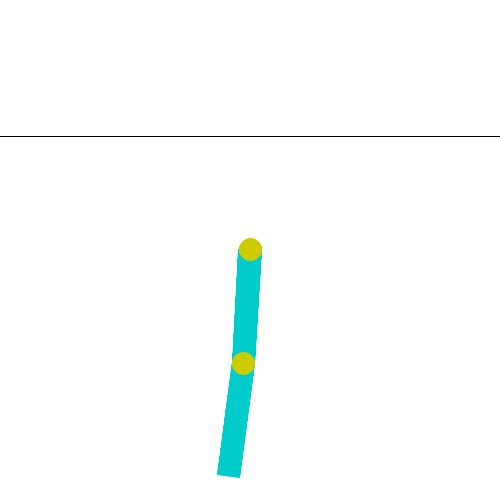

In [21]:
mean_ret, std_ret = evaluate(policy_net, n_episodes=30)
print(f"V6_1 greedy return on {ENV_NAME}: {mean_ret:.1f} +/- {std_ret:.1f}")
print("Scoreboard (greedy):  V0 -421  ->  V3 -88  ->  V4 -85  ->  V5 -85  ->  V6_1 here")
record_gif(policy_net, "v6_1_baseline.gif")

---
*Series complete. V6_0+V6_1 reshaped the loop into the wide-inference / deep-update form real
large-model PPO uses: one batched forward feeds 512 envs, a shuffled `DataLoader` feeds the SGD,
GAE and the autoreset bootstrap run per lane before flattening, and the KL brake caps each
update. The MLP-on-CPU won't saturate a GPU, but the pipeline is the shape that would.*